# 03 · Pakistan, January 2023: the under-frequency cascade
*Companion to* **Biggest Power Grid Failures: Engineering Analysis of History's Most Severe Blackouts, Cascades, and Grid Failures** *by Ganesh Kumar Pandey.* See **Chapter 8, Section 8.2.3**.

Equations (8.1)-(8.2) of the book describe a self-reinforcing loop: each generator that trips on its own
under-frequency protection removes both power ($\Delta P$ grows) and inertia ($H\cdot S$ shrinks), so the
next threshold is reached faster.

This notebook builds an *illustrative* low-demand winter-morning system with thin reserve and generator
trip settings scattered between 49.2 and 48.0 Hz, then asks: what actually stops the cascade?

> **Model note.** This is a simplified teaching model. Parameters are chosen to be plausible and to reproduce the *shape* of the reported event, not to replicate any operator's measured data. For the authoritative record, read the official report cited in the book. No public technical inquiry with unit-level data was available for this event (see ref. [27]),
so the fleet below is synthetic.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
from gridfail import plotstyle as ps
ps.apply()
FIG = os.path.abspath(os.path.join('..', 'figures'))

In [2]:
from gridfail.frequency import FreqSystem, GenLoss, UFTrip, ShedStage, simulate, print_log

FLEET = [UFTrip(49.2, 350, 2500, 0.5, 'IPP A'), UFTrip(49.0, 500, 3500, 0.5, 'IPP B'),
         UFTrip(48.8, 600, 4000, 0.3, 'Thermal C'), UFTrip(48.6, 700, 5000, 0.3, 'Thermal D'),
         UFTrip(48.3, 900, 6000, 0.3, 'Plant E'), UFTrip(48.0, 1200, 8000, 0.2, 'Plant F')]
UFLS = [ShedStage(49.4, 300, 0.2, 'UFLS stage 1'), ShedStage(49.3, 400, 0.2, 'UFLS stage 2'),
        ShedStage(49.2, 500, 0.2, 'UFLS stage 3'), ShedStage(49.1, 600, 0.2, 'UFLS stage 4')]

def pakistan(reserve=200, ufls=False):
    s = FreqSystem(demand_mw=10500, ek_mws=50000, reserve_mw=reserve, reserve_tc=6,
                   load_damping=0.015,
                   losses=[GenLoss(0.0, 500, 3000, 'initiating loss (south)')],
                   uf_trips=FLEET, shed_stages=UFLS if ufls else [])
    return simulate(s, t_end=40, dt=0.005)

cases = {'A. As built: thin reserve (200 MW), no effective UFLS': pakistan(),
         'B. Triple the reserve (600 MW), still no UFLS': pakistan(reserve=600),
         'C. Thin reserve, but UFLS set ABOVE generator trips': pakistan(ufls=True)}

for lab, r in cases.items():
    print('==', lab, '| collapsed:', r['collapsed'])
    print_log(r); print()

== A. As built: thin reserve (200 MW), no effective UFLS | collapsed: True
t=   0.00s  f=50.000 Hz  LOSS      500 MW  initiating loss (south)
t=   4.23s  f=49.122 Hz  TRIP      350 MW  IPP A (UF 49.2 Hz)
t=   5.08s  f=48.835 Hz  TRIP      500 MW  IPP B (UF 49.0 Hz)
t=   5.44s  f=48.608 Hz  TRIP      600 MW  Thermal C (UF 48.8 Hz)
t=   5.75s  f=48.267 Hz  TRIP      700 MW  Thermal D (UF 48.6 Hz)
t=   6.03s  f=47.788 Hz  TRIP      900 MW  Plant E (UF 48.3 Hz)
t=   6.11s  f=47.552 Hz  TRIP     1200 MW  Plant F (UF 48.0 Hz)
t=   6.21s  f=46.997 Hz  BLACKOUT  frequency collapse

== B. Triple the reserve (600 MW), still no UFLS | collapsed: True
t=   0.00s  f=50.000 Hz  LOSS      500 MW  initiating loss (south)
t=   5.78s  f=49.184 Hz  TRIP      350 MW  IPP A (UF 49.2 Hz)
t=   7.18s  f=48.912 Hz  TRIP      500 MW  IPP B (UF 49.0 Hz)
t=   7.72s  f=48.659 Hz  TRIP      600 MW  Thermal C (UF 48.8 Hz)
t=   8.10s  f=48.328 Hz  TRIP      700 MW  Thermal D (UF 48.6 Hz)
t=   8.42s  f=47.845 Hz  TRIP

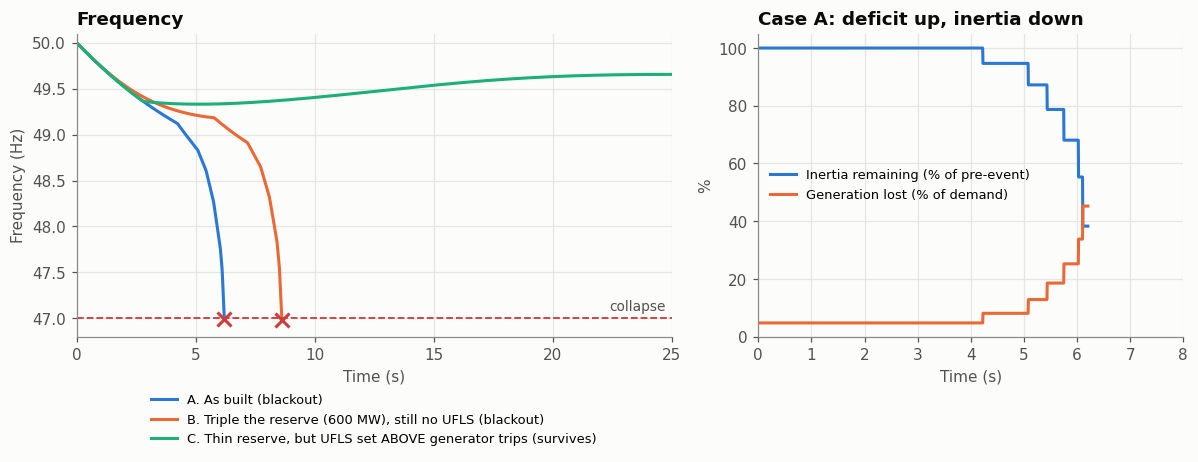

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4), gridspec_kw=dict(width_ratios=[1.4, 1]))
for (lab, r), c in zip(cases.items(), ps.SERIES):
    ax1.plot(r['t'], r['f'], color=c, label=lab.split(':')[0] + (' (blackout)' if r['collapsed'] else ' (survives)'))
    if r['collapsed']:
        k = np.where(np.isnan(r['f']))[0][0] - 1
        ax1.plot(r['t'][k], r['f'][k], 'x', color=ps.CRITICAL, ms=9, mew=2)
ps.threshold(ax1, 47.0, 'collapse')
ax1.set_xlim(0, 25); ax1.set_ylim(46.8, 50.1)
ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Frequency (Hz)')
ax1.set_title('Frequency'); ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=8.5)

r = cases['A. As built: thin reserve (200 MW), no effective UFLS']
k = ~np.isnan(r['f'])
ax2.plot(r['t'][k], 100 * r['ek'][k] / r['ek'][0], color=ps.SERIES[0], label='Inertia remaining (% of pre-event)')
ax2.plot(r['t'][k], 100 * r['lost'][k] / 10500, color=ps.SERIES[1], label='Generation lost (% of demand)')
ax2.set_xlim(0, 8); ax2.set_ylim(0, 105); ax2.set_xlabel('Time (s)'); ax2.set_ylabel('%')
ax2.set_title('Case A: deficit up, inertia down'); ax2.legend(loc='center left', fontsize=8.5)
fig.tight_layout()
fig.savefig(os.path.join(FIG, '03_pakistan_uf_cascade.png'))
plt.show()

**Reading the result.** Tripling the reserve (case B) only delays the collapse by a couple of seconds,
because reserve is *slow* compared with protection. What saves the system is **coordination** (case C):
load-shedding stages set above the generators' own trip thresholds remove demand before the first
generator gives up. That is exactly lesson 2 of Chapter 8: *under-frequency relay settings must be
coordinated to avoid cascade amplification.*